In [1]:
#pd.set_option('display.max_columns', None)

In [2]:
!pip install ~/fwiVis/utility_functions/
! pip install plotnine


Processing /home/jovyan/fwiVis/utility_functions
  Preparing metadata (setup.py) ... done
  Created wheel for fwiVis: filename=fwiVis-0.1-py3-none-any.whl size=19526 sha256=b5eefc386ca524e8eaf24ad854f8fae88f8bfbb74d395c7544904c08112c5a45
  Stored in directory: /tmp/pip-ephem-wheel-cache-f8mz6vdp/wheels/79/0f/3d/08c18473dd7e0fb915900e6b4f13b81f1fa84371f9bf24d864
Successfully built fwiVis
  Attempting uninstall: fwiVis
    Found existing installation: fwiVis 0.1
    Uninstalling fwiVis-0.1:
      Successfully uninstalled fwiVis-0.1


In [3]:
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain

from datetime import date
from bs4 import BeautifulSoup
import requests
import os
import plotnine
import xarray as xr

#import numpy as np
from matplotlib import pyplot as plt
from plotnine import ggplot, geom_point, geom_jitter, aes, stat_smooth, facet_wrap
import plotnine as plotnine
import seaborn as sns


In [4]:
import fwiVis.fwiVis as fv

#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_only/April_1_unmerged_fires_with_FWI.csv"
#path = "/projects/old_shared/fire_weather_vis/Lightning_analysis/fwi_timeline_merge/Final_dataset_as_of_20240209.csv"
#fire3 = fv.prep_fire_files(path)

path = os.path.abspath("data/Quebec_v3_full_data_perimeters20241112.csv")
fire3 = fv.prep_fire_files(path)
fire_first = fire3

path2 = os.path.abspath('data/Quebec_v3_full_data_perimetersMAX_fwi_with_ISI_and_BUIful_timeseries_202535.csv')
fire_max = fv.prep_fire_files(path2)


#ciffc = pd.read_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/CIFFC_data/ciffc_all_canada.csv")
ciffc = pd.read_csv(os.path.abspath("contextual_data/CIFFC_data/ciffc_all_canada.csv"))
ciffc = ciffc[ciffc.field_agency_code == "qc"]


ciffc = gpd.GeoDataFrame(ciffc, geometry= gpd.points_from_xy(ciffc.field_longitude, ciffc.field_latitude), crs = "4326")
ciffc = ciffc.to_crs("3571")

ciffc["geometry_point"] = ciffc.geometry

pre_data_transform =fire_first.sjoin(ciffc)


#ciffc = pd.read_csv("/projects/old_shared/fire_weather_vis/Lightning_analysis/CIFFC_data/ciffc_all_canada.csv")
ciffc_off = pd.read_csv(os.path.abspath("contextual_data/NFDB/NFDB_point_20240613.txt"))
ciffc_off = ciffc_off[ciffc_off.SRC_AGENCY == "QC"]


ciffc_off = gpd.GeoDataFrame(ciffc_off, geometry= gpd.points_from_xy(ciffc_off.LATITUDE, ciffc_off.LONGITUDE), crs = "4326")
ciffc_off = ciffc_off.to_crs("3571")

ciffc_off["geometry_point"] = ciffc_off.geometry ### looks like the NFDB dataset has less info on supression, but has an "out date" column and a "size ha" column that may be more up tot date. 



/tmp/ipykernel_2109/3654062052.py:29: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.


In [5]:
ciffc_off.NFDBFIREID.isin(ciffc.field_agency_fire_id).unique()

array([False])

In [6]:
ciffc

,field_agency_fire_id,field_agency_code,field_agency_data_timezone,field_situation_report_date,field_status_date,field_stage_of_control_status,field_system_fire_cause,field_response_type,field_fire_size,field_latitude,field_longitude,full_count,geometry,geometry_point
403,435,qc,EST,2023-06-05T23:35:00.000Z,2023-11-27T16:56:51.000Z,OUT,H,MOD,5.0,53.7861,-78.9017,6668,POINT (3898742.213 764782.682),POINT (3898742.213 764782.682)
404,396,qc,EST,2023-06-01T18:34:00.000Z,2023-11-27T15:59:57.000Z,OUT,N,FUL,0.7,47.6006,-74.6494,6668,POINT (4456149.411 1223295.467),POINT (4456149.411 1223295.467)
405,633,qc,EST,2023-07-16T03:45:00.000Z,2023-11-27T15:43:00.000Z,OUT,N,MOD,758.8,57.9736,-68.5222,6668,POINT (3282395.654 1291501.11),POINT (3282395.654 1291501.11)
407,483,qc,EST,2023-06-15T03:33:00.000Z,2023-11-27T15:14:25.000Z,OUT,N,MON,425871.9,54.0569,-74.6378,6668,POINT (3803452.719 1044946.264),POINT (3803452.719 1044946.264)
408,498,qc,EST,2023-06-22T00:57:00.000Z,2023-11-27T15:12:18.000Z,OUT,N,MON,26230.0,54.5289,-77.7439,6668,POINT (3805615.05 826704.299),POINT (3805615.05 826704.299)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5912,2,qc,EST,2023-04-08T21:15:00.000Z,2023-05-14T20:00:16.000Z,OUT,H,FUL,0.1,45.3497,-72.6489,6668,POINT (4632549.998 1447412.32),POINT (4632549.998 1447412.32)
6547,1,qc,EST,2023-01-08T03:00:00.000Z,2023-04-20T18:12:36.000Z,OUT,N,FUL,0.0,50.3050,-66.4394,6668,POINT (3977595.964 1734512.613),POINT (3977595.964 1734512.613)
6664,636,qc,EDT,2020-07-17T20:50:00.000Z,2020-07-17T20:50:00.000Z,OC,N,MON,0.0,52.4708,-77.7369,6668,POINT (4018092.418 873375.429),POINT (4018092.418 873375.429)
6665,559,qc,EDT,2003-07-01T20:30:00.000Z,2003-07-01T20:30:00.000Z,OC,N,MON,5835.5,54.6678,-73.1356,6668,POINT (3712795.409 1125514.124),POINT (3712795.409 1125514.124)


In [7]:
ciffc_off.columns

Index(['FID', 'NFDBFIREID', 'SRC_AGENCY', 'NAT_PARK', 'FIRE_ID', 'FIRENAME',
       'LATITUDE', 'LONGITUDE', 'YEAR', 'MONTH', 'DAY', 'REP_DATE',
       'ATTK_DATE', 'OUT_DATE', 'SIZE_HA', 'CAUSE', 'CAUSE2', 'FIRE_TYPE',
       'RESPONSE', 'PROTZONE', 'PRESCRIBED', 'MORE_INFO', 'CFS_NOTE1',
       'CFS_NOTE2', 'ACQ_DATE', 'geometry', 'geometry_point'],
      dtype='object')

In [8]:
fire3 = fire3.sort_values(by = ["fireID", "t"])
fire_max = fire_max.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]
fire_max = fire_max[~fire_max.FWI.isna()]
# df = fire3[fire3.fireID == '2367']
# df

In [9]:

def corrected_farea_diff(df, var = "farea"):
    #sub_df = df[]
    df[f"{var}_diff"] = df[var].diff()
    min_t = df.t.min()
    if(np.isnan(*df.loc[df.t == min_t, [f"{var}_diff"]].values)):
        df.loc[df.t == min_t, [f"{var}_diff"]] = df.loc[df.t == min_t, [f"{var}"]].values
    else:
        print("Error! First value not NaN")
        df = None
    return(df)

def just_the_igs(df,): ## Reminder that this will only acocunt for the earliest ignition from a multi-fire complex. 

    df["is_ig"] = False
    df.loc[df.t == df.t.min(), ['is_ig']] = True
    
    return(df)

def extinction(df, days_past = 1):
    df.loc[:, ['is_ext']] = False
    df.loc[:, ["t"]] = df.t.astype("datetime64[ns]")
    final_t = df[df.n_newpixels > 0].t.astype("datetime64[ns]").max()
    post_fire = final_t + timedelta(days = days_past)

    if (pd.isnull(np.datetime64(str(final_t)))):
        df.loc[(df.t == df.t.min()), ['is_ext']] = True
    else:
        df.loc[(df.t  > final_t)  & (df.t  <= post_fire), ['is_ext']] = True
    #print(final_t)
    #print(df.fireID.unique())
    #print(len(df[df["is_ext"] == True]))
    return(df)


fire3 = fire3[~fire3.FWI.isna()]

post_fr = fire3

post_fr = post_fr.groupby("fireID").apply(extinction).reset_index(drop = True)
post_fr = post_fr.groupby("fireID").apply(just_the_igs).reset_index(drop = True)

fire3 = fire3.groupby("fireID").apply(corrected_farea_diff).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(just_the_igs).reset_index(drop = True)
fire3["frac_change"] = fire3.groupby("fireID").farea.pct_change()
#fire3.farea = fire3.farea.astype("int64")
fire3 = fire3.sjoin(ciffc)
fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()
fire_max["farea_diff"] = fire_max.groupby("fireID").farea.diff()
row_mask = (~fire3.fireID.str.contains("_"))

#fire3[row_mask].hvplot.scatter(x='FWI', y='farea_diff', hover_cols=['fireID', 't'])
#fire3[row_mask].plot.scatter(x='FWI', y='farea_diff')

/tmp/ipykernel_2109/3198965904.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2109/3198965904.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2109/3198965904.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pas

In [10]:
supression = fire3.groupby("fireID").field_response_type.unique().reset_index()
supression

supression["len"] = supression.field_response_type.apply(len)

multi_suppress_ids = supression[supression.len> 1].fireID

supression[supression.len> 1]
fire_ids_not_unique_supression = supression[supression.len> 1].fireID

In [11]:
### Function that takes a point and looks for the multi polygons that intersect with that point. 
#It then assignes just the polygon portion of the multipolygon with the point's ID. 
# At the end, I want to put in an ID where there are two supression stratagies, and I want to get two IDs out, one per supression stratagy: subset to just the portion where there is one supression strategy.  
# I have found one fire so far (1082) where this wont work, because at least some probable fire that could/should be tied to one surpession strategy doesn't overlap with the point, even after the reported time, and by the time out polygon overlapped with the point it was already merged with anouther one. So boo. 

import shapely
import shapely.geometry as gmt
from shapely.geometry import MultiPolygon, Point, Polygon

def split_multipolygon(multipolygon, point):
    """Splits a MultiPolygon into separate polygons based on intersection with a point.

    Args:
        multipolygon (MultiPolygon): The MultiPolygon to split.
        point (Point): The point used to determine intersection.

    Returns:
        list: A list of individual polygons.
    """

    polygons = []
    for polygon in multipolygon:
        if polygon.intersects(point):
            polygons.append(polygon)
    return polygons


def exactly_one_true(lst):
    """Checks if exactly one element in the list is True."""
    return sum(lst) == 1

def sep_supression(fid, df1,  meter_crs = 3571, point_crs = 4326): #df2,
    print("Assuming df1 is in  crs 4326, and df2 is in a metered crs (35")
    df = df1[df1.fireID == fid]
    #df2 = df2[df2.fireID == fid]
    #df = df[30:40]
    # df = df.to_crs(meter_crs)
    # df.geometry = df.geometry.buffer(500) ## 200 meeters
    # df = df.to_crs(point_crs)
    ciffc_resp = df.field_response_type.unique()
    resp_l = []
    #for r in ciffc_resp:
    just_intersect = []
    #unique_points = df[["field_latitude", "field_longitude", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True) # (df.field_response_type == r)
    #unique_points = gpd.GeoDataFrame(unique_points, geometry= gpd.points_from_xy(unique_points.field_longitude, unique_points.field_latitude,  crs = 4326))

    unique_points = df[["geometry_point", "field_response_type", "field_agency_fire_id"]].drop_duplicates().reset_index(drop = True)
    unique_points = gpd.GeoDataFrame(unique_points, geometry= unique_points.geometry_point,  crs = 3571)
    #return(unique_points)
    #points = [Point(lon, lat) for lon, lat in zip(unique_points.field_longitude, unique_points.field_latitude)]
    points = unique_points.geometry_point
    #print(len(points))
    #return(points)
    
    for index, row in df.iterrows(): # [df.field_response_type == r]
    #if isinstance(row['geometry'], MultiPolygon):
        #print("This is a multipolygon")
       #split_polygons = split_multipolygon(row['geometry'], intersection_point)
        ## Double check that only 1 point intersects with polygon. 
        if(isinstance(row['geometry'], Polygon)):
            row['geometry'] = gmt.MultiPolygon([row['geometry']])
        for polygon in row['geometry'].geoms:
            #print(shapely.intersects(points, polygon))
            unique_points["Does_it_intersect"] = np.nan
            intersecting_points = []
            for point in points:
                intersecting_points.append(polygon.intersects(point))
                    
            unique_points["Does_it_intersect"] = intersecting_points
            up_group = unique_points.groupby("field_response_type").Does_it_intersect.unique().reset_index()
            #return(up_group)

            only_one_type_of_supression_intersects = (sum(up_group.Does_it_intersect.explode().values) == 1)
            #intersecting_points = [point for point in points if polygon.intersects(point)]
            #print(intersecting_points)

            #if len(intersecting_points) == 1:  # Exactly one point intersects
            if only_one_type_of_supression_intersects: ### Only one catagory intersects with this polygon
                #print(only_one_type_of_supression_intersects)
                #return(up_group)
                new_row = row.copy()
                new_row["geometry"] = polygon
                new_row["farea"] = (polygon.area / (1000 * 1000))
                new_row["fperim"] = np.nan
                new_row["meanFRP"] = np.nan
                
                
                
                # try:
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.sum()].field_response_type.iloc[0])# tmp2[tmp2.source.explode()].degree.iloc[0]
                    #new_row["fireID"] = str(fid) + "." +str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0]) + "." + str(*unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.unique())
                sup = str(up_group[up_group.Does_it_intersect.apply(any)].field_response_type.iloc[0])
                new_row["fireID"] = str(fid) + "." + sup +"." +  ".".join(unique_points[unique_points.Does_it_intersect == True].field_agency_fire_id.astype("str"))
                new_row["field_response_type"] = sup
                    
                # except:
                #     return(unique_points)
                # #     return(up_group)
                    
                just_intersect.append(new_row)
                # fig, ax = plt.subplots(figsize=(8, 6))
                # #print(type(new_row))
                # #new_row.plot(color = "green")
                # plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "green")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.show()
            else:
                new_row = row.copy()
                new_row["geometry"] = polygon
                # fig, ax = plt.subplots(figsize=(8, 6))
                # plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                # for point in points:
                #     ax.plot(point.x, point.y, 'ro', label="Point")  # 'ro' for red points
                
                #     # Adjust the plot
                #     ax.set_title("Geometry and Points")
                #     ax.set_xlabel("Longitude")
                #     ax.set_ylabel("Latitude")
                #     plt.grid(True)
                    
                #     # Show the plot
                #     plt.show()
                #plt.plot(*new_row["geometry"].exterior.xy, color = "yellow")
                #plt.plot(unique_points.field_longitude, unique_points.field_latitude,  color = "red")
                #plt.plot(*unique_points["geometry"].exterior.xy, color = "red")
                #unique_points.plot(color = "red")
                #plt.show()
                #print("skipping")
                #just_intersect.append(None)
    # else:
    #     just_intersect.append(row)
    just_intersect_df = gpd.GeoDataFrame(just_intersect)
    just_intersect_df = gpd.GeoDataFrame(just_intersect_df, geometry = just_intersect_df.geometry, crs = 3571)
    #just_intersect_df = just_intersect_df[just_intersect_df.field_response_type == sup] # Dropping false lable
    just_intersect_df = just_intersect_df.drop_duplicates()
    # if(len(just_intersect_df) > 0):
    #     #print(just_intersect)
    #     just_intersect_df.fireID = just_intersect_df.fireID.astype("str") + "." + r
    #     #print(just_intersect_df)
    #     resp_l.append(just_intersect_df)
    # else:
    #     print(f"{fid} had no independant multi-polygons to split")
#full_df = pd.concat(resp_l, axis=0)
    return(just_intersect_df)
    

def check_that_continious_record(df):
    min_t = df.t.min()
    max_t = df.t.max()
    #dates = pd.date_range(start= min_t, end=  max_t).to_pydatetime().tolist()
    dates = pd.date_range(start= min_t, end=  max_t).strftime('%Y-%m-%d 12:00:00').tolist()
    len_df = len(df.t.unique())
    #print(df.t.unique())
    len_seq = len(dates)
    #print(dates)
    if(len_df != len_seq):
        print(f"FireID {df.fireID.unique()} is not a continious sequence.")
        return(False)
    d_list = []
    for d in dates:
        some_dates = df[df.t == d]
        d_list.append(len(some_dates) > 0)
    return(any(d_list))

In [12]:
### remake IDs with duel supression status 


skip_list = ["1082", 
            "1324"] ### has more than one supression, but seems like the reported point doesn't overlap with an indepandant multipolygon. 

duel_sup =  [item for item in fire_ids_not_unique_supression if item not in skip_list]
dfs = []
for s in duel_sup:
    print(s)
    tmp = sep_supression(str(s), fire3)
    dfs.append(tmp)
foo = pd.concat(dfs)

foo = gpd.GeoDataFrame(foo, geometry = foo.geometry, crs = 3571)
#foo = foo.set_crs(4326)


#### Check that there is a continious t 


bools = foo.groupby("fireID").apply(check_that_continious_record)
print(f"Are all the fires continuios records???: {all(bools)}")

if(all(bools)):
    fire3 = fire3[~fire3.fireID.isin(fire_ids_not_unique_supression)]
    foo = foo.to_crs(fire3.crs)
    fire3 = pd.concat([fire3, foo], ignore_index=True)

1088
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
226
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2545
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2647
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
2649
Assuming df1 is in  crs 4326, and df2 is in a metered crs (35
Are all the fires continuios records???: True


/tmp/ipykernel_2109/919185589.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [13]:
def chop_fires_at_end(df):
    final_t = df[df.n_newpixels > 0].t.max()
    df = df[df.t <= final_t]
    return(df)

#post_fr = fire3.groupby("fireID").apply(extinction).reset_index(drop = True)
fire3 = fire3.groupby("fireID").apply(chop_fires_at_end).reset_index(drop = True)


fire3 = fire3.sort_values(by = ["fireID", "t"])
fire3 = fire3[~fire3.FWI.isna()]

/tmp/ipykernel_2109/455317430.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [14]:
#fire3["farea_diff"] = fire3.groupby("fireID").farea.diff()
#fire3 = fire3.groupby("fireID").apply(corrected_farea_diff)
fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(3).max().reset_index(drop = True)
fire3["FWI_diff"] = fire3.groupby("fireID").FWI.diff()

fire3["farea_diff_stand"] = fire3.groupby("fireID").farea.diff()



## Fireline 
fire3["flinelen_shifted"] = fire3.groupby("fireID").flinelen.shift(periods = 1)
fire3["fperim_shifted"] = fire3.groupby("fireID").fperim.shift(periods = 1)
fire3["flinelen_diff"] = fire3.groupby("fireID").flinelen.diff()
fire3["fperim_diff"] = fire3.groupby("fireID").fperim.diff()


### Some useful vars to color by 
def assign_day_of_fire(df):
    df = df.sort_values(by = "t")
    df['day_of_fire'] = df.t.rank()
    #df['day_of_fire'] = df['day_of_fire'].astype("int64")
    return(df)


def get_max_duration(df):
    max_duration = df.duration.max()
    df["max_duration"] = max_duration


# fire3 = fire3.groupby("fireID").apply(assign_day_of_fire).reset_index(drop = True)
# fire3["farea_shifted"] = fire3.groupby("fireID").farea.shift(periods = 1)

# fire3["normalized_farea_diff"] = fire3.farea_diff/fire3.farea_shifted



fire3["GEOS_IMERGEARLY"] = fire3["GEOS-5.IMERGEARLY"]

def line_trend(data):
    # df = df.sort_values(by = "t")
    # df["time_delta"] = df.t.astype("datetime64[ns]") - df.t.astype("datetime64[ns]").min()
    
    # df["t_float"] = df["time_delta"].dt.days

    seq = range(0, (len(data)), 1) ##  Create an even sequence to represent FWI in time. 
    z = np.polyfit(seq, data, 1)
    #df[f"line_trend_{var}"] = z[0] ## Slope of trend line
    return(z[0])


In [15]:

### Implementing FBP technical handbook equation 88 https://drive.google.com/file/d/1xBseasON22KFC4jEVBKk75EOuUK-dpM2/view

#1) Calculate the length and breadth of the fires. Simple way, get just the convex hull and the longer one is length. More complex, length shoudl maybe be tied to where active fire line is (to represent head fire?)
from shapely.geometry import LineString

def get_length_to_breadth(polygon):
    
    mbr_points = list(zip(*polygon.minimum_rotated_rectangle.exterior.coords.xy)) ### oh no projection issues? 
    # calculate the length of each side of the minimum bounding rectangle
    mbr_lengths = [LineString((mbr_points[i], mbr_points[i+1])).length for i in range(len(mbr_points) - 1)]

    # get major/minor axis measurements
    minor_axis = min(mbr_lengths)
    major_axis = max(mbr_lengths)
    
    return(major_axis/minor_axis)



fire3["LB"] = fire3.geometry.apply(get_length_to_breadth)


## Calculate spread rate

row_mask = (fire3.fperim_diff > 0.1) & (fire3.flinelen > 0)
perimeter_growth_rate = fire3[row_mask]["fperim_diff"] ### Modify by length of active fire line? 
LB = fire3[row_mask]["LB"]

def get_perimeter_growth_rate(df):
    term_a = ((1/df["LB"]) + 1) # will this vectorize? 
    term_b =  1 + (((df["LB"] - 1) / (2 * (df["LB"] + 1)))**2)

    df["tot_ros_all_perim"] = 2 * (df["fperim_diff"] / (term_a * term_b)) ### Will have same units as perimeter growth in m/ 24 hour. Not area. 
    df["tot_ros_flinelen_shifted"] = 2 * (df["flinelen_shifted"] / (term_a * term_b)) ### Will have same units as perimeter growth in m/ 24 hour. Not area. 
    return(df)



fire3 = fire3.groupby("fireID").apply(get_perimeter_growth_rate).reset_index(drop = True)

# fire3["spread_rate"] = np.nan
# fire3.loc[row_mask, "spread_rate"] = 1/(2*((np.pi * (1+(1/LB)) * (1 + ((LB -1)/(2*(LB+1)))**2)) / perimeter_growth_rate ))


# fire3["flinelen_rolling"]  = fire3.groupby("fireID").flinelen.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["flinelen_diff_rolling"] = fire3.groupby("fireID").flinelen_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["fperim_rolling"] = fire3.groupby("fireID").fperim.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["fperim_diff_rolling"] = fire3.groupby("fireID").fperim_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["spread_rate_rolling"] = fire3.groupby("fireID").spread_rate.rolling(rolling_num).agg(agg_function).reset_index(drop = True)


# long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
# #fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

# row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

/tmp/ipykernel_2109/2227942284.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


In [16]:
y_vals = ["farea_diff", "farea_diff_stand", "flinelen", "flinelen_diff", 'tot_ros_all_perim', 'tot_ros_flinelen_shifted']
rolling_nums = [3, 7]
agg_functions = ["mean", "max", line_trend] ## Need to do line_trend seperately. 
#agg_function = "max" # max


def str_fix(string):
    try:
        fin_str = string.__name__
    except:
        fin_str = string
    return(str(fin_str))

fire3 = fire3.sort_values(by = ["fireID", "t"]) ## Needs t to be sorted for trend line calculation
x_rolling = ["GEOS_IMERGEARLY", "FWI"]
x_rolling2 = x_rolling.copy()
y_vals1 = y_vals.copy()
for rolling_num in rolling_nums:
    
    for xr in x_rolling:
        # var_name_tmp = f"{xr}_rolling_{rolling_num}_line_trend"
        # fire3[var_name_tmp] = fire3.groupby("fireID").rolling(rolling_num).agg(line_trend, var = xr).reset_index(drop = True)
        # x_rolling2.append(var_name_tmp)
        for agg_function in agg_functions:
            var_name_tmp = f"{xr}_rolling_{rolling_num}_{str_fix(agg_function)}"
            fire3.loc[:, [var_name_tmp]] = fire3.groupby("fireID")[xr].rolling(rolling_num).agg(agg_function).reset_index(drop = True)
            x_rolling2.append(var_name_tmp)
    for yv in y_vals:
        for agg_function in agg_functions:
            var_name_tmp = f"{yv}_rolling_{rolling_num}_{str_fix(agg_function)}"
            fire3.loc[:, [var_name_tmp]] = fire3.groupby("fireID")[yv].rolling(rolling_num).agg(agg_function).reset_index(drop = True)
            y_vals1.append(var_name_tmp)

# fire3["FWI_rolling"] = fire3.groupby("fireID").FWI.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["FWI_diff_rolling"] = fire3.groupby("fireID").FWI_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3['farea_rolling'] = fire3.groupby("fireID").farea.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3['farea_diff_rolling'] = fire3.groupby("fireID").farea_diff.rolling(rolling_num).agg(agg_function).reset_index(drop = True)
# fire3["GEOS-5.IMERGEARLY_rolling"] = fire3.groupby("fireID")["GEOS-5.IMERGEARLY"].rolling(rolling_num).agg(agg_function).reset_index(drop = True)

#long_fires = fire3[fire3.day_of_fire > 3].fireID.unique()
#fire3['max_dof'] = fire3.groupby("fireID").day_of_fire.max()

#row_mask = (~fire3.fireID.str.contains("_")) & (fire3.farea_diff > 0.1) & (fire3.fireID.isin(long_fires)) #& fire3['max_dof'] >= 3#& (fire3.max_duration >= 3)

## Check CIFFC ignitions

In [17]:
### Fires in CIFFC not in FEDS
## Note, there is a fire in here that intersects with the fires I discarded becuase they had different ignitions from the stars. 1082

# exlcluded_fires = ['467', '534', '488', '535'] ## Ciffc id for fires taht overlap with fires I discarded bc of multiple supression ignitions. 

# cif_fires = ciffc[~ciffc.field_agency_fire_id.isin(fire3.field_agency_fire_id)]
# cif_fires = cif_fires[~cif_fires.field_agency_fire_id.isin(exlcluded_fires)]


cif_fires = ciffc[~ciffc.field_agency_fire_id.isin(pre_data_transform.field_agency_fire_id)]

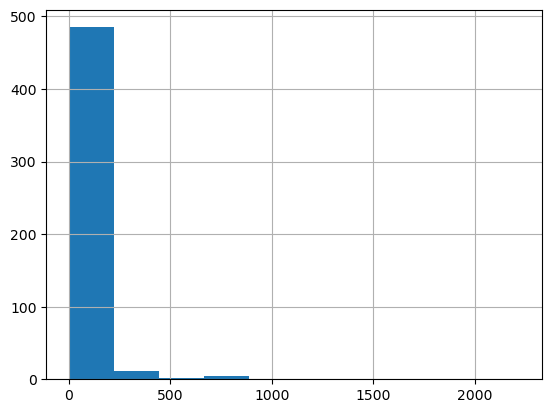

In [18]:
cif_fires.field_fire_size.hist() ## There is one large fire i guess FEDS missed
cif_fires = cif_fires[cif_fires.field_fire_size <= 400] ### only the ones we "should" have tracked



### Make  plot that shows the # of ignitions through time and the % that would go on to grow large (N vs S breakdown)?

#ciffc_grps = ciffc.groupby()

ciffc["field_situation_report_date_no_tz"] = ciffc.field_situation_report_date.str.replace(".000Z", "")
ciffc["field_situation_report_date_no_tz"] = ciffc.field_situation_report_date_no_tz.astype("datetime64[ns]")
ciffc["field_situation_report_date_no_tz"] = ciffc.field_situation_report_date_no_tz.dt.strftime("%Y-%m-%d")


def get_percent_over(series, thresh = 400):
    tot = len(series)
    sub_len = len(series[series >= thresh])
    if(sub_len == 0):
        percent_over = 0
    else:
        percent_over = sub_len / tot
    return(percent_over)
        #print(f"Nothing is over {thresh}")
    
    

ciffc_counts=ciffc.groupby("field_situation_report_date_no_tz").field_agency_fire_id.count().reset_index()
ciffc_counts= ciffc_counts.rename( columns = {"field_agency_fire_id": "num_fire_starts"})

ciffc_counts["percent_large"] = ciffc.groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)

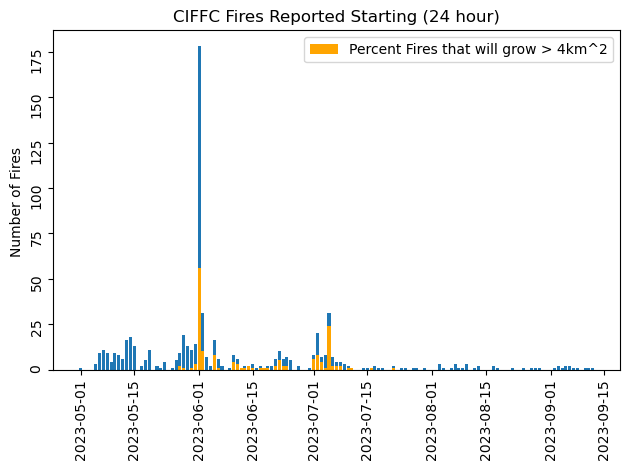

In [19]:
ciffc_counts = ciffc_counts[ciffc_counts.field_situation_report_date_no_tz >= "2023-05-01"]

ciffc_counts = ciffc_counts[ciffc_counts.field_situation_report_date_no_tz <= "2023-09-15"]


plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts)
plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts * ciffc_counts.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.ylabel("Number of Fires ")
plt.legend()
plt.tick_params(rotation=90)
plt.title("CIFFC Fires Reported Starting (24 hour)")
plt.tight_layout()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/ciffc_percent_igs.png')

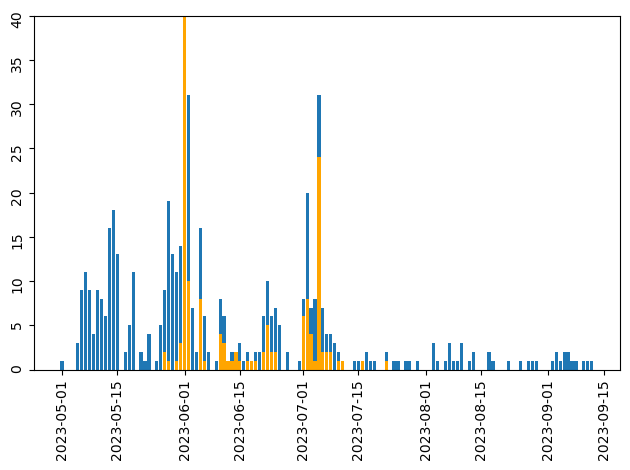

In [20]:

plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts)
plt.bar(ciffc_counts.field_situation_report_date_no_tz.astype("datetime64[ns]"), ciffc_counts.num_fire_starts * ciffc_counts.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.ylim((0,40))
#plt.ylabel("Number of Fires ")
#plt.legend()
plt.tick_params(rotation=90)
#plt.title("CIFFC Fires Reported Starting (24 hour)")
plt.tight_layout()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc_percent_igs_broken_yaxis.png')

In [21]:
#FWI_data_south = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv")
FWI_data_south = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/001.SouthernEcoregions_FullResponseZone.FWI.raw.chiclet.csv')

#FWI_data_north = pd.read_csv("https://portal.nccs.nasa.gov/datashare/GlobalFWI/ForecastFWIEXPERIMENTAL/QuebecEcoSuppressionRegions/GEOS-5/GEOS-5.IMERGEARLY/90_P/chicletDataNoSmoothing/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv")

FWI_data_north = pd.read_csv(f'{os.path.abspath("contextual_data/")}/Local_chiclet_csv/002.NorthernEcoregions_LimitedResponseZone.FWI.raw.chiclet.csv')


fwis = FWI_data_south[["INITDATE", "0"]]
fwis = fwis.rename(columns={"0":"GEOS_5"})
fwis = fwis.rename(columns={"INITDATE":"t"})
fwis.t = fwis.t.astype("datetime64[ns]")


fwin = FWI_data_north[["INITDATE", "0"]]
fwin = fwin.rename(columns={"0":"GEOS_5"})
fwin = fwin.rename(columns={"INITDATE":"t"})
fwin.t = fwin.t.astype("datetime64[ns]")

In [22]:
## Quick plot of extinctions, also correlations between FWI and Igs ve Exticts for the two regions


# ciffc_off_high = ciffc_off[ciffc_off.LATITUDE >= 51.5] ## Aproximatly the average of the supression boarder
# ciffc_off_high = ciffc_off[ciffc_off.LATITUDE < 51.5] ## Aproximatly the average of the supression boarder

# ciffc_off_high_counts=ciffc_off_high.groupby("OUT_DATE").FIRE_ID.count().reset_index()
# ciffc_off_high_counts= ciffc_off_high_counts.rename( columns = {"FIRE_ID": "num_fire_exts"})

#ciffc_off_high_counts["percent_large"] = ciffc_off_high_counts.groupby("OUT_DATE").SIZE_HA.apply(get_percent_over).reset_index(drop = True)









In [23]:
ciffc_counts_high =ciffc[ciffc.field_latitude >= 51.5].groupby("field_situation_report_date_no_tz").field_agency_fire_id.count().reset_index()
ciffc_counts_high= ciffc_counts_high.rename( columns = {"field_agency_fire_id": "num_fire_starts"})

ciffc_counts_high["percent_large"] = ciffc[ciffc.field_latitude >= 51.5].groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)


ciffc_counts_high.loc[:, "t"] = ciffc_counts_high["field_situation_report_date_no_tz"].astype("datetime64[ns]")
#ciffc_counts_high["percent_large"] = ciffc_counts_high.groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)

ciffc_counts_high = ciffc_counts_high.merge(fwin)


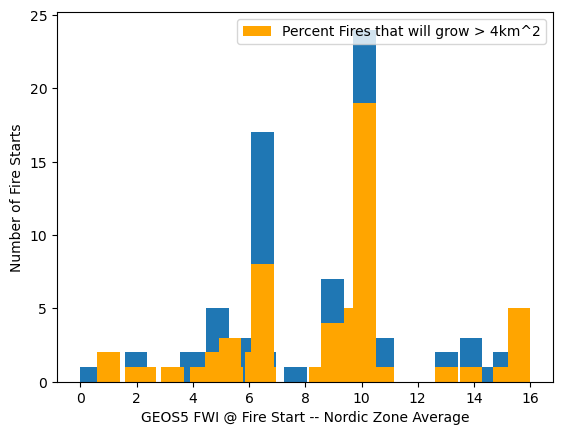

In [24]:
#plt.scatter(ciffc_counts_high.GEOS_5, ciffc_counts_high.num_fire_starts)
plt.bar(ciffc_counts_high.GEOS_5, ciffc_counts_high.num_fire_starts)
plt.bar(ciffc_counts_high.GEOS_5, ciffc_counts_high.num_fire_starts * ciffc_counts_high.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.xlabel("GEOS5 FWI @ Fire Start -- Nordic Zone Average")
plt.ylabel("Number of Fire Starts")
plt.legend()
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/north_zone_percent_igs.png')

In [25]:

ciffc_counts_low =ciffc[ciffc.field_latitude < 51.5].groupby("field_situation_report_date_no_tz").field_agency_fire_id.count().reset_index()
ciffc_counts_low= ciffc_counts_low.rename( columns = {"field_agency_fire_id": "num_fire_starts"})

ciffc_counts_low["percent_large"] = ciffc[ciffc.field_latitude < 51.5].groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)


ciffc_counts_low.loc[:, "t"] = ciffc_counts_low["field_situation_report_date_no_tz"].astype("datetime64[ns]")
#ciffc_counts_low["percent_large"] = ciffc_counts_low.groupby("field_situation_report_date_no_tz").field_fire_size.apply(get_percent_over).reset_index(drop = True)

ciffc_counts_low = ciffc_counts_low.merge(fwis)

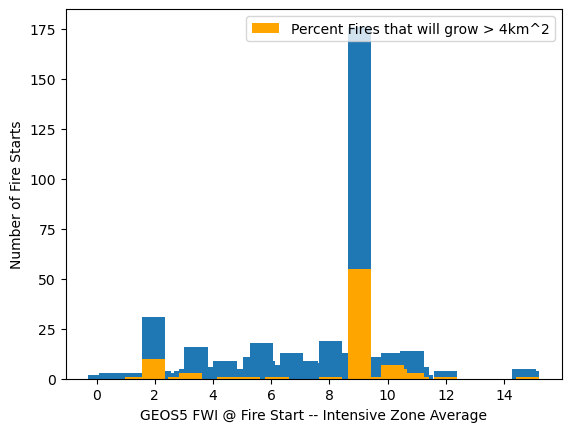

In [26]:
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts)
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts * ciffc_counts_low.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.xlabel("GEOS5 FWI @ Fire Start -- Intensive Zone Average")
plt.ylabel("Number of Fire Starts")
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/south_zone_percent_igs.png')
plt.legend()

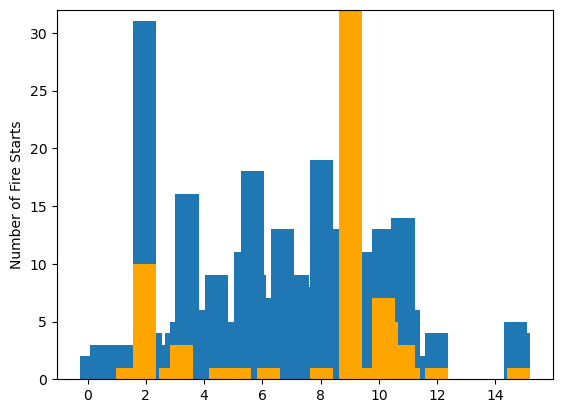

In [27]:
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts)
plt.bar(ciffc_counts_low.GEOS_5, ciffc_counts_low.num_fire_starts * ciffc_counts_low.percent_large, color = "orange", label = "Percent Fires that will grow > 4km^2")
plt.ylim((0, 32))
#plt.xlabel("GEOS5 FWI @ Fire Start -- Intensive Zone Average")
plt.ylabel("Number of Fire Starts")
plt.savefig(f'{os.path.abspath("exploratory_figs")}/ciffc/south_brokeny_zone_percent_igs.png')
#plt.legend()

In [28]:




thresh = 1
thresh_relative = 0.05
def get_num_fires(df, thresh = thresh, var = "farea_diff_stand"):
    n = len(df[df[var] > thresh].fireID.unique())
    return(n)

def get_percent_fires_spread(df, thresh = thresh, var = "farea_diff_stand"):
    
    n = len(df.fireID.unique())
    n_thresh = len(df[df[var] > thresh].fireID.unique())
    if(n == 0):
        print(f"{n} fires on the landscape.")
        return(n)
    return(n_thresh/n)
    
num_fires = fire3.groupby("t").apply(get_num_fires).reset_index()
num_fires_rel_growth = fire3.groupby("t").apply(lambda x: get_num_fires(x, thresh = thresh_relative, var = "frac_change")).reset_index()
percent_fires = fire3.groupby("t").apply(get_percent_fires_spread).reset_index()
percent_fires.rename(columns={0 : "percent_fires"})
percent_fires.loc[:,"FWI_spread"] = ""
num_fires.rename(columns={0 : "num_fires"})
num_fires.loc[:,"FWI_spread"] = ""
num_fires_rel_growth.rename(columns={0 : "num_fires"})
num_fires_rel_growth.loc[:, "FWI_spread"] = ""

FWI_var = 'GEOS_IMERGEARLY'#"GEOS-5.IMERGEARLY"
#def get_fwi_spread_at_day(df, num_fires = num_fires, FWI_var = "GEOS-5.IMERGEARLY"):
df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in num_fires.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    num_fires.loc[num_fires.t == t, "FWI_spread"] =  str(tmp)

df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in percent_fires.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    percent_fires.loc[percent_fires.t == t, "FWI_spread"] =  str(tmp)


df = fire3.copy()
df = df[["t", "fireID", FWI_var]].drop_duplicates()
for t in num_fires_rel_growth.t:
    fwi_vals = df[df.t == t].groupby("fireID")[FWI_var].max() ## Should only be one value
    counts = df[df.t == t].groupby("fireID")[FWI_var].count().reset_index()
    if(any(counts[FWI_var] > 1)):
        print(f"Multiple FWI value for specific date \n {counts[counts[FWI_var] >1]}")
    tmp = fwi_vals.agg(list)
    num_fires_rel_growth.loc[num_fires_rel_growth.t == t, "FWI_spread"] =  str(tmp)

/tmp/ipykernel_2109/2600564061.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2109/2600564061.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2109/2600564061.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pas

In [29]:
import ast

# Convert to a list of actual Python lists
converted_lists = [ast.literal_eval(x) for x in num_fires['FWI_spread']]
flattened_list = [item for sublist in converted_lists for item in sublist]


In [30]:


def condense_by_num_fires_spreading(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]

    df.loc[:, "max_fwi"] =  np.max(flattened_list)
    df.loc[:, "min_fwi"] = np.min(flattened_list)
    df.loc[:, "mean_fwi"] = np.mean(flattened_list)
    df.loc[:, "all_vals"] = str(flattened_list)
    df.loc[:, "75_percent"] = np.quantile(flattened_list, 0.75)
    df.loc[:, "25_percent"] = np.quantile(flattened_list, 0.25)
    df.loc[:, "975_percent"] = np.quantile(flattened_list, 0.975)
    df.loc[:, "025_percent"] = np.quantile(flattened_list, 0.025)
    
    

    return(df)
    
# def condense_by_num_fires_spreading(df):

#      #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
#     converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
#     flattened_list = [item for sublist in converted_lists for item in sublist]

#     df.loc[:, "max_fwi"] =  np.max(flattened_list)
#     df.loc[:, "min_fwi"] = np.min(flattened_list)
#     df.loc[:, "mean_fwi"] = np.mean(flattened_list)
#     df.loc[:, "all_vals"] = str(flattened_list)
#     df.loc[:, "75_percent"] = np.quantile(flattened_list, 0.75)
#     df.loc[:, "25_percent"] = np.quantile(flattened_list, 0.25)
#     df.loc[:, "975_percent"] = np.quantile(flattened_list, 0.975)
#     df.loc[:, "025_percent"] = np.quantile(flattened_list, 0.025)
    
    

#     return(df)

def num_fires_spreading_FWI_vals(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]

    return(flattened_list)

def num_fires_spreading_long_df(df):

     #actual_list = [float(x) for x in df[df.t == t].FWI_spread.strip('[]').split(',')
    converted_lists = [ast.literal_eval(x) for x in df['FWI_spread']]
    flattened_list = [item for sublist in converted_lists for item in sublist]
    new_df = pd.DataFrame({"FWI_spread": flattened_list, 
                            })
    new_df.loc[:, "num_fires"] = df[0]

    return(new_df)
    

    
        
num_test = num_fires.copy()

num_test = num_test.groupby(0).apply(condense_by_num_fires_spreading)

num_test = num_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
num_test = num_test.rename(columns = {0: "num_fires"})
vals = num_fires.groupby(0).t.count()
num_test["day_count"] = ""
#num_test["day_count"] = num_test["day_count"].map(vals)
num_test["day_count"] = vals.values


percent_test = percent_fires.copy()
percent_test = percent_test.groupby(0).apply(condense_by_num_fires_spreading)

percent_test = percent_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
percent_test = percent_test.rename(columns = {0: "percent_fires"})
vals = percent_fires.groupby(0).t.count()
percent_test["day_count"] = ""
percent_test["day_count"] = vals.values

percent_test_sm = percent_fires.copy()
percent_test_sm[0] = percent_test_sm[0].round(1)
percent_test_sm = percent_test_sm.groupby(0).apply(condense_by_num_fires_spreading).reset_index(drop = True)
percent_fires_rn = percent_fires.copy()
percent_fires_rn[0] = percent_fires_rn[0].round(1)
vals = percent_fires_rn.groupby(0).t.count()


percent_test_sm = percent_test_sm[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
percent_test_sm = percent_test_sm.rename(columns = {0: "percent_fires"})
percent_test_sm["day_count"] = ""
#percent_test_sm["day_count"] = percent_test_sm["day_count"].map(vals)
percent_test_sm["day_count"] = vals.values

#num_test_raw = num_test.groupby("num_fires").apply(condense_by_num_fires_spreading)

# num_test_raw = num_fires.copy()

# num_test_raw = num_test_raw.groupby(0).apply(num_fires_spreading_long_df).reset_index()


num_fires_rel_growth_test  = num_fires_rel_growth.copy()
num_fires_rel_growth_test = num_fires_rel_growth_test.groupby(0).apply(condense_by_num_fires_spreading)
num_fires_rel_growth_test = num_fires_rel_growth_test[[0, "max_fwi", 'mean_fwi', 'min_fwi', "025_percent", "975_percent", "25_percent", "75_percent"]].drop_duplicates()
num_fires_rel_growth_test = num_fires_rel_growth_test.rename(columns = {0: "num_fires"})
vals = num_fires_rel_growth.groupby(0).t.count()
num_fires_rel_growth_test["day_count"] = ""
num_fires_rel_growth_test["day_count"] = vals.values


/tmp/ipykernel_2109/3511856844.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2109/3511856844.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2109/3511856844.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pas

In [31]:
# ## Plot FWI distributions as a function of # of fires spreading

# num_test_raw = num_test_raw.dropna()
# num_test_raw.num_fires = num_test_raw.num_fires.astype("int")
# sns.violinplot(data=num_test_raw, x="num_fires", y="FWI_spread", split=True, inner = None, cut=0, density_norm = "width")

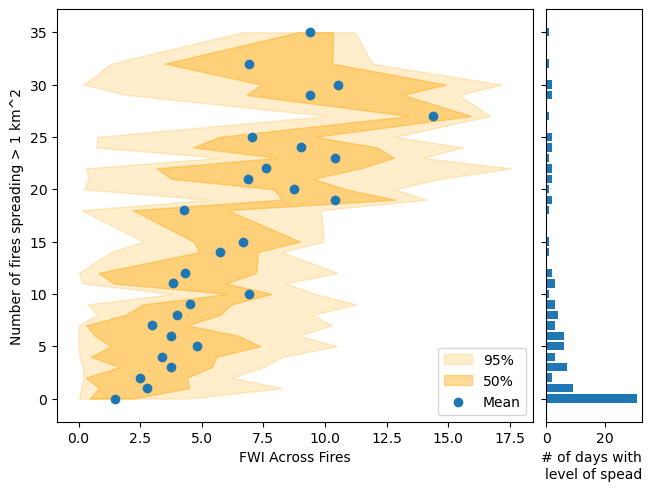

In [32]:

#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(1, 2, gridspec_kw={ 'width_ratios': [5,1]},sharey=True, constrained_layout=True)

# Plot the data on the axes
ax.fill_betweenx(y = num_test.num_fires, x1 =num_test['025_percent'], x2 = num_test['975_percent'], alpha = 0.2, color = "orange", label = "95%")
ax.fill_betweenx(y = num_test.num_fires, x1 =num_test['25_percent'], x2 = num_test['75_percent'], alpha = 0.4, color = "orange", label = "50%")
ax.scatter(y = num_test.num_fires, x = num_test.mean_fwi, label = "Mean")
ax.legend()



#### Hist plot

# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Number of fires spreading > {thresh} km^2")


ax2.barh(num_test.num_fires, num_test.day_count)
#ax2.set_yscale("log")
ax2.set_xlabel("# of days with \nlevel of spead")
#ax2.xaxis.set_visible(False)






# Ensure x-axis is visible on top plot and ticks are at the bottom
#ax.xaxis.set_visible(True)
#ax.xaxis.tick_bottom()

####### Customize the plot
# ax2.set_xticks(range(len(categories)))
# ax2.set_xticklabels(categories)
# ax2.set_ylabel('Count')
# ax2.set_title('Stem and Leaf-Style Plot with Colored Points')

# # Move x-axis to the top
# ax2.xaxis.tick_top()
# ax2.xaxis.set_label_position('top')

# # Invert y-axis
# ax2.invert_yaxis()

# # Set y-axis limits and ticks
# ax2.set_ylim(max_count, -0.5)
# ax2.set_yticks(range(max_count))
# ax2.set_yticklabels(range(max_count, 0, -1))

# # Remove all spines
# for spine in ax.spines.values():
#     spine.set_visible(False)

# # Add a horizontal colorbar at the top
# cbar_ax = fig.add_axes([0.1, 0.95, 0.8, 0.02])
# cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Quality')


# plt.subplots_adjust(top=0.85)  # Adjust top margin for colorbar
#plt.constrained_layout()
plt.savefig(f"some_figs/fires_spread_fwi_distribution/number_fires_spread_{thresh}.png")

plt.show()


# Display the plot

# plt.scatter(num_test.num_fires, num_test.max_fwi, color = "orange", alpha = 0.2)
# plt.scatter(num_test.num_fires, num_test.min_fwi, color = "orange", alpha = 0.2)
# plt.scatter(num_test.num_fires, num_test.mean_fwi)

#num_test

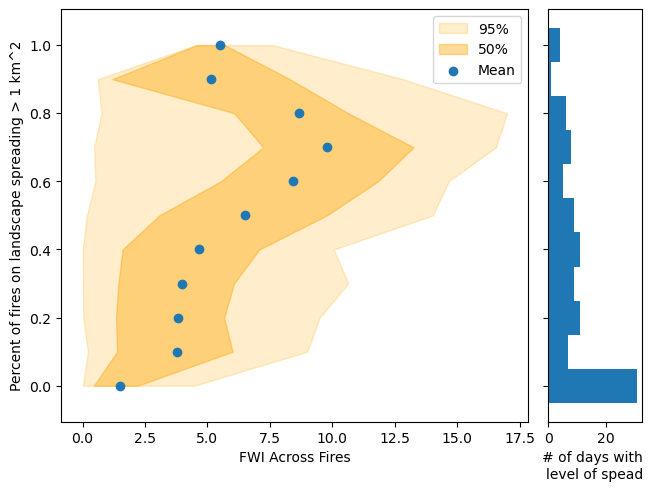

In [33]:
fig, ([ax, ax2]) = plt.subplots(1,2, gridspec_kw={'width_ratios': [5, 1]},sharey=True, constrained_layout=True)

# Plot the data on the axes
ax.fill_betweenx(y = percent_test_sm.percent_fires, x1 =percent_test_sm['025_percent'], x2 = percent_test_sm['975_percent'], alpha = 0.2, color = "orange", label = "95%")
ax.fill_betweenx(y = percent_test_sm.percent_fires, x1 =percent_test_sm['25_percent'], x2 = percent_test_sm['75_percent'], alpha = 0.4, color = "orange", label = "50%")
ax.scatter( percent_test_sm.mean_fwi, percent_test_sm.percent_fires, label = "Mean")
ax.legend()



# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Percent of fires on landscape spreading > {thresh} km^2")
ax2.barh(percent_test_sm.percent_fires, percent_test_sm.day_count, height = 0.1)
#ax2.set_yscale("log")
ax2.set_xlabel("# of days with \nlevel of spead")
plt.savefig(f"some_figs/fires_spread_fwi_distribution/pecent_fires_spread_{thresh}.png")
plt.show()

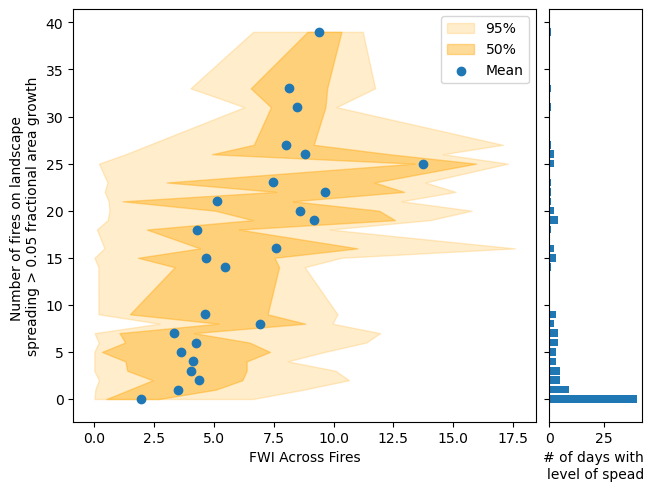

In [34]:
fig, ([ax, ax2]) = plt.subplots(1,2, gridspec_kw={'width_ratios': [5, 1]},sharey=True, constrained_layout=True)

# Plot the data on the axes
ax.fill_betweenx(y = num_fires_rel_growth_test.num_fires, x1 =num_fires_rel_growth_test['025_percent'], x2 = num_fires_rel_growth_test['975_percent'], alpha = 0.2, color = "orange", label = "95%")
ax.fill_betweenx(y = num_fires_rel_growth_test.num_fires, x1 =num_fires_rel_growth_test['25_percent'], x2 = num_fires_rel_growth_test['75_percent'], alpha = 0.4, color = "orange", label = "50%")
ax.scatter( num_fires_rel_growth_test.mean_fwi, num_fires_rel_growth_test.num_fires, label = "Mean")
ax.legend()



# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Number of fires on landscape \nspreading > {thresh_relative} fractional area growth")
ax2.barh(num_fires_rel_growth_test.num_fires,num_fires_rel_growth_test.day_count)
#ax2.set_yscale("log")
ax2.set_xlabel("# of days with \nlevel of spead")
#plt.savefig(f"some_figs/fires_spread_fwi_distribution/num_fires_relative_spread_{thresh_relative}.png")
plt.show()

In [35]:
## Merge both df's together to get the dates tied to a specific # of fires and vice versa
num_fires = num_fires.rename(columns = {0: "num_fires"})
percent_fires = percent_fires.rename(columns = {0: "percent_fires"})

#percent_test = percent_test.reset_index()
#percent_test = percent_test.rename(columns = {0: "num_fires"})


num_merge = num_test.reset_index(drop = True).merge(num_fires.reset_index(drop = True), on = "num_fires" )
percent_merge = percent_test.reset_index(drop = True).merge(percent_fires.reset_index(drop = True), on = "percent_fires")

# #Sample data
# categories = ['A', 'B', 'C', 'D', 'E']
# counts = [12, 8, 15, 6, 10]
# qualities = [
#     np.random.uniform(0, 1, 12),
#     np.random.uniform(0, 1, 8),
#     np.random.uniform(0, 1, 15),
#     np.random.uniform(0, 1, 6),
#     np.random.uniform(0, 1, 10)
# ]

counts = num_merge.day_count
categories = num_merge.num_fires

pcounts = percent_merge.day_count
pcategories = percent_merge.percent_fires

tmin = num_merge.t.astype("datetime64[ns]").min()
num_merge[f"days_since"] = num_merge.t.astype("datetime64[ns]") - tmin
percent_merge[f"days_since"] = percent_merge.t.astype("datetime64[ns]") - tmin

num_merge[f"days_since_{tmin}"] = num_merge[f"days_since"].dt.days
percent_merge[f"days_since_{tmin}"] = percent_merge[f"days_since"].dt.days

qualities = num_merge[f"days_since_{tmin}"].astype("int")#num_merge.t.astype("datetime64[ns]").dt.hours()
pqualities = percent_merge[f"days_since_{tmin}"].astype("int")
# # Create the plot
# fig, ax = plt.subplots(figsize=(12, 8))

# # Calculate point size to make them touch
# max_count = max(counts)
# point_size = (1 / max_count) * ax.get_window_extent().height

# for i, (category, count, quality) in enumerate(zip(categories, counts, qualities)):
#     x = [i] * count
#     y = np.arange(count)
    
#     scatter = ax.scatter(x, y, c=quality, cmap='viridis', s=point_size, edgecolor='none')

# # Customize the plot
# ax.set_xticks(range(len(categories)))
# ax.set_xticklabels(categories)
# ax.set_ylabel('Count')
# ax.set_title('Bar Graph-Style Plot with Aligned, Touching Colored Points')

# # Set y-axis limits and ticks
# ax.set_ylim(-0.5, max_count - 0.5)
# ax.set_yticks(range(0, max_count, 5))

# # Remove top and right spines
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Add a colorbar
# cbar = plt.colorbar(scatter)
# cbar.set_label('Quality')

# plt.tight_layout()
# plt.show()

[0, 48, 49, 50, 58, 59, 60, 61, 62, 72, 73, 74, 77, 79, 80, 81, 82, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 98, 99, 100, 101]
[1, 56, 57, 71, 83, 84, 85, 96, 97]
[54, 78]
[10, 16, 51, 55, 64, 75, 76]
[17, 47, 65]
[2, 18, 28, 37, 63, 66]
[15, 27, 31, 67, 68, 70]
[30, 32, 36]
[11, 29, 41, 53]
[9, 33, 52]
[69]
[8, 14, 46]
[7, 39]
[42]
[19]
[38]
[12, 21]
[6]
[40, 43]
[26, 44]
[20]
[13, 24]
[3, 45]
[22]
[25, 34]
[5, 23]
[35]
[4]


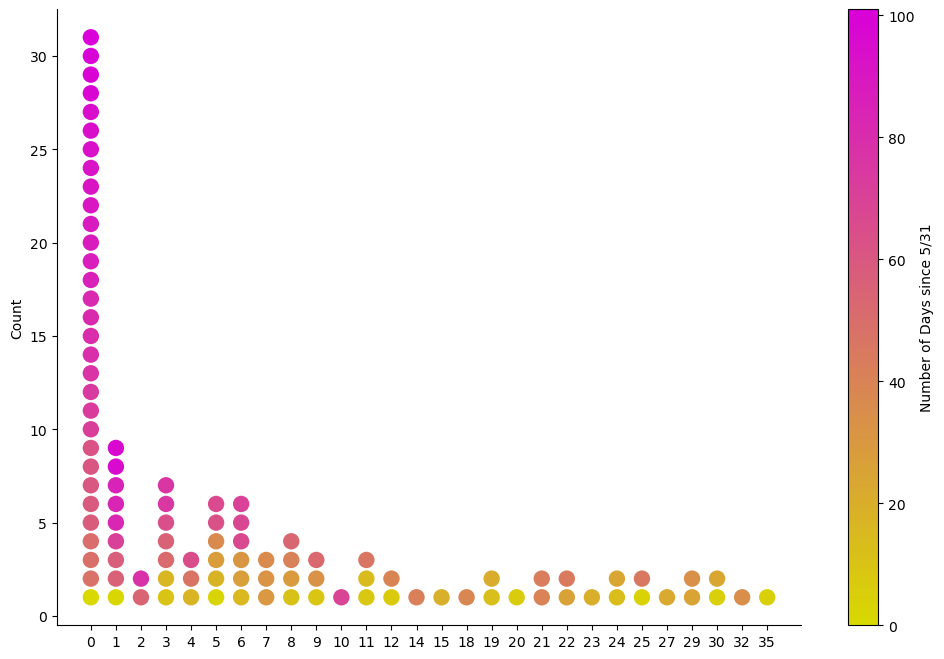

In [36]:
import matplotlib.cm as cm

import matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
import colorsys

# Retrieve the original colormap
original_cmap = plt.get_cmap('spring_r')

def create_darker_colormap(base_cmap_name, darkness_factor):
    """
    Create a darker version of a given colormap.
    
    Parameters:
    - base_cmap_name: str, the name of the base colormap.
    - darkness_factor: float, a factor between 0 and 1 to darken the colormap.
                       1 means no change, 0 means completely dark.
    
    Returns:
    - LinearSegmentedColormap: a new colormap that is a darker version of the base colormap.
    """
    # Retrieve the original colormap
    base_cmap = plt.get_cmap(base_cmap_name)
    
    # Create a list of colors from the colormap and darken them
    colors = base_cmap(np.linspace(0, 1, 256))
    colors[:, :3] *= darkness_factor
    colors = np.clip(colors, 0, 1)  # Ensure values are within [0, 1]
    
    # Create the new colormap
    return LinearSegmentedColormap.from_list(f"{base_cmap_name}_darker", colors)

def darken_color(color, scale):
    """Darkens a color by scaling its lightness in HLS space.

    Args:
        color: An RGB tuple, hex code, or color name.
        scale: A value between 0 and 1 to scale the lightness (0 is black, 1 is no change).

    Returns:
        A darkened color in RGB tuple format.
    """
    
    rgb = mc.to_rgb(color)
    hls = colorsys.rgb_to_hls(*rgb)
    new_lightness = hls[1] * scale
    new_rgb = colorsys.hls_to_rgb(hls[0], new_lightness, hls[2])
    return new_rgb
    

# Define the darkness factor (between 0 and 1)
darkness_factor = 0.85

# Create a custom colormap with the specified darkness factor
darker_cmap = create_darker_colormap('spring_r', darkness_factor)

# data = {
#     'category': ['A', 'B', 'C', 'D', 'E'] * 10,
#     'count': np.random.randint(1, 6, 50),
#     'quality': np.random.uniform(0, 1, 50)
# }
# df = pd.DataFrame(data)

df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate point size to make them touch
max_count = df_agg['day_count'].max()
point_size = (1 / max_count) * ax.get_window_extent().height
#val_range = np.arange(df[f'days_since_{tmin}'].max() + 1)

cmap = cm.viridis
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())


# Create a ScalarMappable
scalar_map = cm.ScalarMappable(cmap=cmap)
scalar_map.set_array([])

# Map values to RGBA colors
#rgba_colors = scalar_map.to_rgba(val_range / (df[f'days_since_{tmin}'].max() + 1))

for i, row in df_agg.iterrows():
    category = row['num_fires']
    count = row['day_count']
    qualities = row[f'days_since_{tmin}']
    #qualities[:]  = [x /  (df[f'days_since_{tmin}'].max() + 1) for x in qualities]
    print(qualities)
    x = [i] * count
    y = np.arange(count) + 1
    
    #scatter = ax.scatter(x, y, c=qualities, cmap='viridis', s=point_size*7, edgecolor='none')
    #scatter = ax.scatter(x, y, c=scalar_map.to_rgba(qualities), s=point_size*7, edgecolor='none')
    scatter = ax.scatter(x, y, c = qualities, cmap=darker_cmap, norm = norm,  s=point_size*7, edgecolor='none')

# Customize the plot
ax.set_xticks(range(len(df_agg)))
ax.set_xticklabels(df_agg['num_fires'])
ax.set_ylabel('Count')
#ax.set_title('Bar Graph-Style Plot with Aligned, Touching Colored Points')

# Set y-axis limits and ticks
#ax.set_ylim(-0.5, max_count - 0.5)
#ax.set_yticks(range(0, max_count + 1))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Days since 5/31')

#plt.tight_layout()
plt.show()


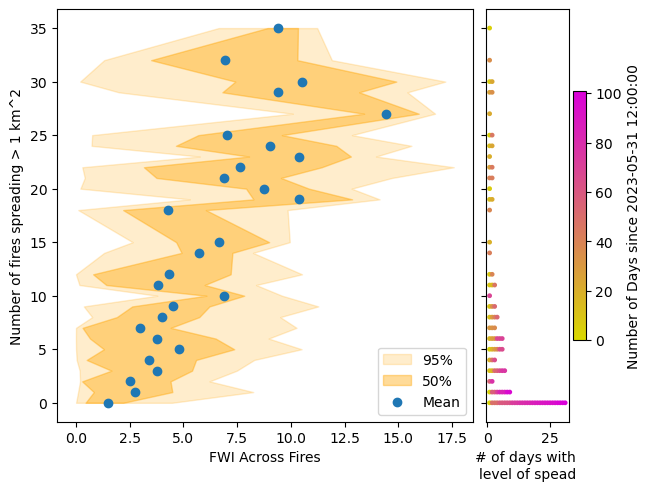

In [37]:
## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(1, 2, gridspec_kw={ 'width_ratios': [10,2]},sharey=True, constrained_layout=True) # 

# Plot the data on the axes
ax.fill_betweenx(y = num_test.num_fires, x1 =num_test['025_percent'], x2 = num_test['975_percent'], alpha = 0.2, color = "orange", label = "95%")
ax.fill_betweenx(y = num_test.num_fires, x1 =num_test['25_percent'], x2 = num_test['75_percent'], alpha = 0.4, color = "orange", label = "50%")
ax.scatter(y = num_test.num_fires, x = num_test.mean_fwi, label = "Mean")
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Number of fires spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df.groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(x, y, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax2.set_xlabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
cbar = fig.colorbar(sm, ax = ax2, orientation='vertical', label = f"Number of Days since {tmin}")
#plt.savefig(f"some_figs/fires_spread_fwi_distribution/with_dots_number_fires_spread_{thresh}.png")

plt.show()

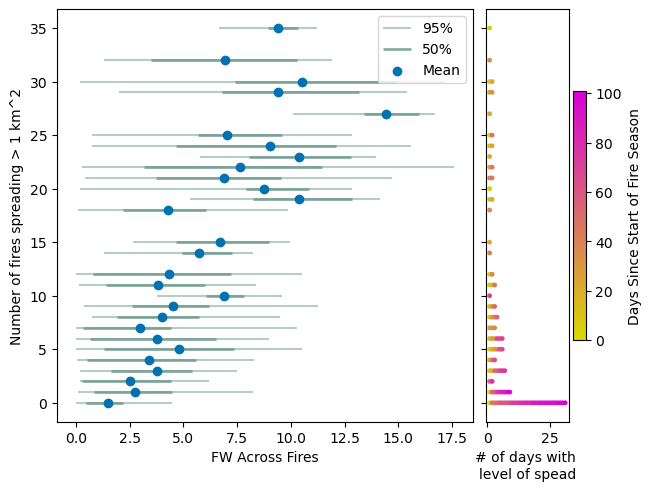

In [38]:
## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(1, 2, gridspec_kw={ 'width_ratios': [10,2]},sharey=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.hlines(y = num_test.num_fires, xmin =num_test['025_percent'], xmax = num_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.hlines(y = num_test.num_fires, xmin =num_test['25_percent'], xmax = num_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(y = num_test.num_fires, x = num_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FW Across Fires")
ax.set_ylabel(f"Number of fires spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df.groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(x, y, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax2.set_xlabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
cbar = fig.colorbar(sm, ax = ax2, orientation='vertical', label = f"Days Since Start of Fire Season")
plt.savefig(f"some_figs/fires_spread_fwi_distribution/cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()

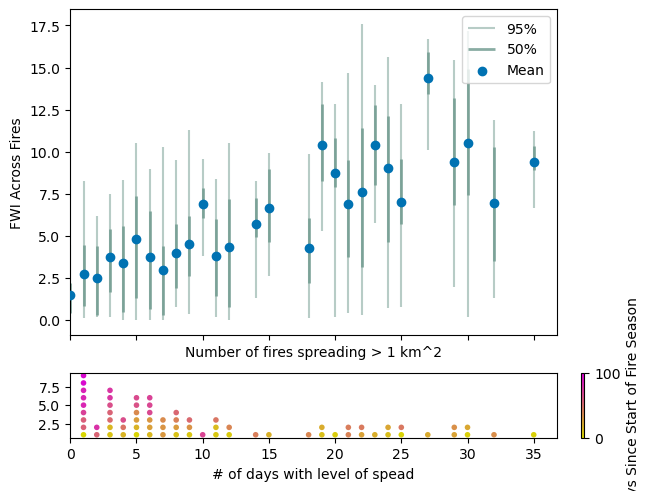

In [39]:
### Try without zeros

## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(2, 1, gridspec_kw={ 'height_ratios': [10,2]},sharex=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.vlines(x = num_test.num_fires, ymin =num_test['025_percent'], ymax = num_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.vlines(x = num_test.num_fires, ymin =num_test['25_percent'], ymax = num_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(x = num_test.num_fires, y = num_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_ylabel("FWI Across Fires")
ax.set_xlabel(f"Number of fires spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height * 9
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df[df.num_fires > 0].groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(y, x, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    ax2.set_xlim(xmin = 0)
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax2.set_xlabel("# of days with level of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
cbar = fig.colorbar(sm, ax = ax2, label = f"Days Since Start of Fire Season") #  orientation='horizontal'
plt.savefig(f"some_figs/fires_spread_fwi_distribution/reverse_axis_no_zeros_cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()

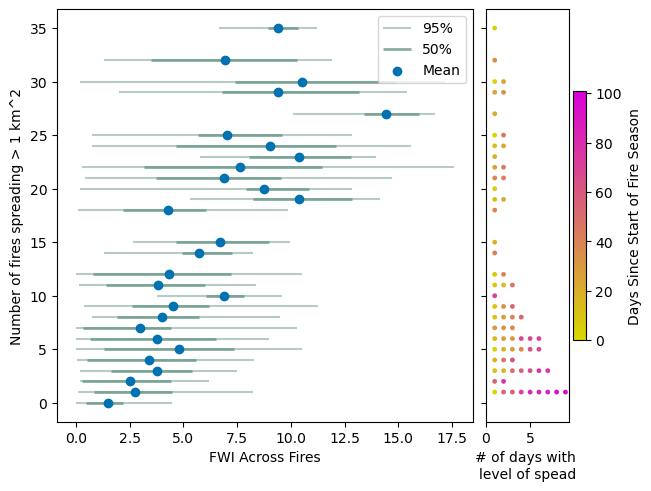

In [40]:
### Try without zeros

## combining both plots


df = num_merge[['num_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('num_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(1, 2, gridspec_kw={ 'width_ratios': [10,2]},sharey=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.hlines(y = num_test.num_fires, xmin =num_test['025_percent'], xmax = num_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.hlines(y = num_test.num_fires, xmin =num_test['25_percent'], xmax = num_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(y = num_test.num_fires, x = num_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Number of fires spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(num_test.num_fires, num_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height
# for i, row in df_agg.iterrows():
#     category = row['num_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for category, group in df[df.num_fires > 0].groupby('num_fires'):
    count = group['day_count'].iloc[0]
    qualities = group[f'days_since_{tmin}'].tolist()
    y_value = category #group['num_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x = np.arange(count) + 1
    y = [y_value] * count
    
    ax2.scatter(x, y, c=qualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    ax2.set_xlim(xmin = 0)
# categories = df['num_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['num_fires'])
ax2.set_xlabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
cbar = fig.colorbar(sm, ax = ax2, orientation='vertical', label = f"Days Since Start of Fire Season")
plt.savefig(f"some_figs/fires_spread_fwi_distribution/no_zeros_cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()



pecount 2
pqualities [56, 57]
pcategory 0.05555555555555555
x [1 2]
y [0.05555555555555555, 0.05555555555555555]
pecount 1
pqualities [16]
pcategory 0.08333333333333333
x [1]
y [0.08333333333333333]
pecount 1
pqualities [10]
pcategory 0.08823529411764706
x [1]
y [0.08823529411764706]
pecount 1
pqualities [54]
pcategory 0.1
x [1]
y [0.1]
pecount 1
pqualities [17]
pcategory 0.10810810810810811
x [1]
y [0.10810810810810811]
pecount 1
pqualities [18]
pcategory 0.13157894736842105
x [1]
y [0.13157894736842105]
pecount 2
pqualities [51, 55]
pcategory 0.15
x [1 2]
y [0.15, 0.15]
pecount 1
pqualities [37]
pcategory 0.16129032258064516
x [1]
y [0.16129032258064516]
pecount 3
pqualities [1, 15, 71]
pcategory 0.16666666666666666
x [1 2 3]
y [0.16666666666666666, 0.16666666666666666, 0.16666666666666666]
pecount 1
pqualities [64]
pcategory 0.17647058823529413
x [1]
y [0.17647058823529413]
pecount 2
pqualities [2, 47]
pcategory 0.2
x [1 2]
y [0.2, 0.2]
pecount 1
pqualities [11]
pcategory 0.22222222

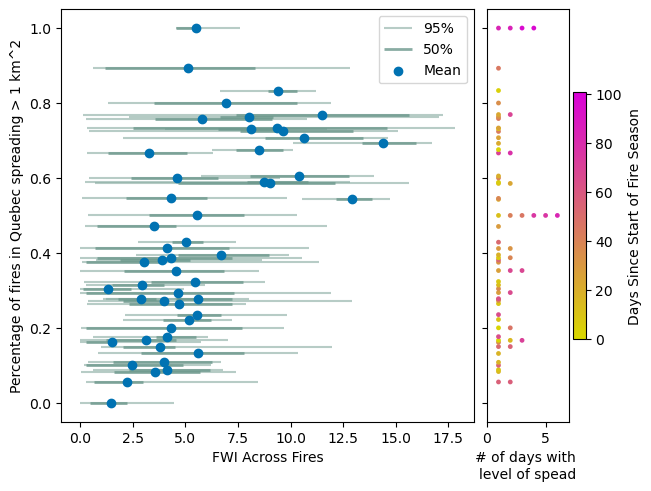

In [41]:
### percentage as a opposed to number

# Fixing percent merge's day-count numbers

# for i in percent_merge.percent_fires.unique():
#     percent_merge.loc[percent_merge.percent_fires == i, "day_count"] = len(percent_merge[percent_merge.percent_fires == i].t.unique())

## combining both plots


df = percent_merge[['percent_fires','day_count',f'days_since_{tmin}']]

# Correct aggregation: take the first count for each category (since they're repeated)
df_agg = df.groupby('percent_fires').agg({'day_count': 'first', f'days_since_{tmin}': list}).reset_index()
max_count = df_agg['day_count'].max()


#fig1, ([ax, ax2],  [ax5, ax6], [ax3, ax4]) = plt.subplots(3,2, gridspec_kw={'width_ratios':[100,4], 'height_ratios': [1,5, 1]}, constrained_layout=True)
fig, ([ax, ax2]) = plt.subplots(1, 2, gridspec_kw={ 'width_ratios': [10,2]},sharey=True, constrained_layout=True) # 

# Plot the data on the axes
point_color = "#0072B2"
line_color = "#87ABA1"
dark_line_color = darken_color(line_color, scale = darkness_factor)
ax.hlines(y = percent_test.percent_fires, xmin =percent_test['025_percent'], xmax = percent_test['975_percent'], alpha = 0.6, color = line_color, label = "95%", zorder = 1)
ax.hlines(y = percent_test.percent_fires, xmin =percent_test['25_percent'], xmax = percent_test['75_percent'], alpha = 0.8, linewidth=2, color = dark_line_color, label = "50%", zorder = 2)
ax.scatter(y = percent_test.percent_fires, x = percent_test.mean_fwi, label = "Mean", color = point_color, zorder = 3)
ax.legend()




# Set the title of the plot
ax.set_title("")

# Set the labels for the x and y axes
ax.set_xlabel("FWI Across Fires")
ax.set_ylabel(f"Percentage of fires in Quebec spreading > {thresh} km^2")

#### Dot plot
# ax2.barh(percent_test.percent_fires, percent_test.day_count)
# #ax2.set_yscale("log")
# ax2.set_xlabel("# of days with \nlevel of spead")
# #ax2.xaxis.set_visible(False)
point_size = (1 / max_count) * ax2.get_window_extent().height
# for i, row in df_agg.iterrows():
#     category = row['percent_fires']
#     count = row['day_count']
#     qualities = row[f'days_since_{tmin}']
    
#     y = [i] * count
#     #y = category
#     x = np.arange(count)
    
#     scatter = ax2.scatter(x, y, c=qualities[:count], cmap='viridis', s=point_size*0.7, edgecolor='none')
cmap = cm.spring_r
norm = plt.Normalize(0, df[f'days_since_{tmin}'].max())

for pcategory, group in df[df.percent_fires > 0].groupby('percent_fires'):
    pcount = group['day_count'].iloc[0]
    print("pecount", pcount)
    pqualities = group[f'days_since_{tmin}'].tolist()
    print("pqualities", pqualities)
    
    y_value = pcategory #group['percent_fires'].iloc[0]  # Assuming you have a 'y_value' column that matches your scatter plot
    print("pcategory", pcategory)
    #print(str(y_value) + " : Number of fires")
    #print(str(qualities) + ": days since")
    x =  np.arange(pcount) + 1
    y = [y_value] * pcount
    print("x", x)
    print("y", y)
    
    ax2.scatter(x, y, c=pqualities, cmap=darker_cmap, norm = norm, s=point_size, edgecolor='none') # 'spring_r' # qualities[:count]
    ax2.set_xlim(xmin = 0, xmax = df[df.percent_fires > 0].day_count.max() + 1)
# categories = df['percent_fires'].unique()
# ax2.set_yticks(range(len(categories)))
#ax2.set_y=yticks(range(len(df_agg)))
#ax.set_xticklabels(df_agg['percent_fires'])
ax2.set_xlabel("# of days with \nlevel of spead")
# cbar = plt.colorbar(ax2)
# cbar.set_label('Days Past 5/31')
sm =  ScalarMappable(norm=norm, cmap = darker_cmap)
cbar = fig.colorbar(sm, ax = ax2, orientation='vertical', label = f"Days Since Start of Fire Season")
plt.savefig(f"some_figs/fires_spread_fwi_distribution/percent_no_zeros_cbar_with_dots_number_fires_spread_{thresh}.png")

plt.show()

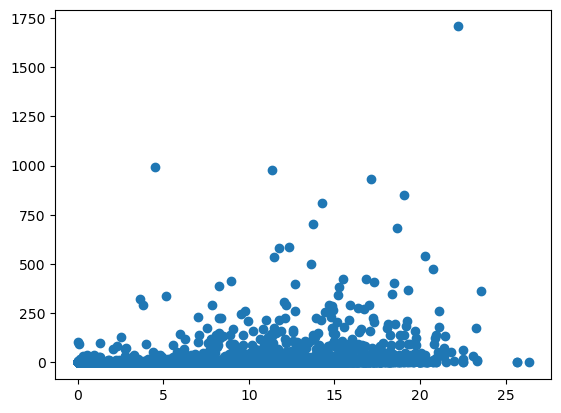

In [42]:
plt.scatter(fire_max['GEOS-5.IMERGEARLY'], fire_max.farea_diff)

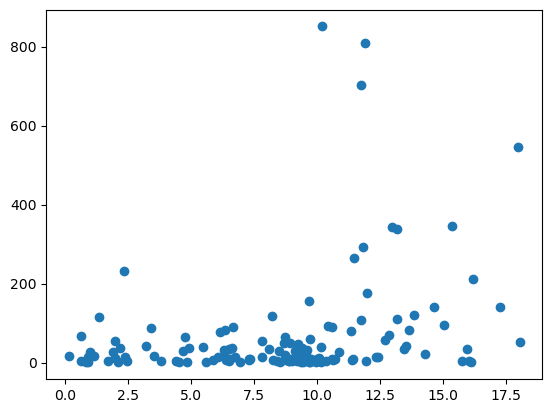

In [43]:
max_spread_increment = fire3.groupby("fireID").farea_diff_stand.max().reset_index()
max_spread_increment = max_spread_increment.merge(fire3, on = ["fireID", "farea_diff_stand"])


plt.scatter(max_spread_increment.GEOS_IMERGEARLY, max_spread_increment.farea_diff_stand)

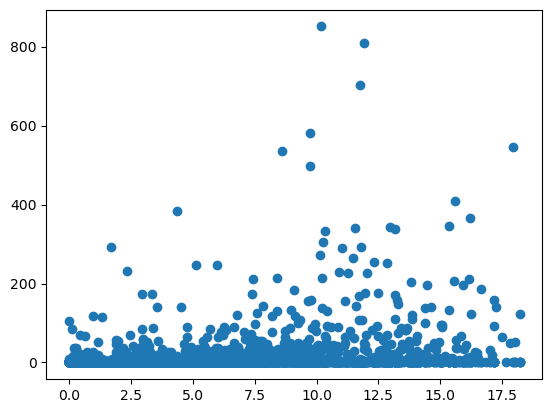

In [44]:
plt.scatter(fire3.GEOS_IMERGEARLY, fire3.farea_diff_stand)